# Pipe4: 
## To classify severity of damage - minor, moderate or severe.


In [2]:
# Enable inline plotting for Jupyter Notebook
%matplotlib inline  

import urllib
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from IPython.display import Image, display, clear_output
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Seaborn settings
sns.set_style('whitegrid')
sns.set_palette("cubehelix")

In [3]:
# TensorFlow/Keras Imports
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2, l1
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint

In [6]:
def save_bottleneck_features(location):
    datagen = ImageDataGenerator(rescale=1./255)  
    model = VGG16(include_top=False, weights='imagenet')

    # Training Data Generator
    train_generator = datagen.flow_from_directory(
        train_data_dir,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode=None,
        shuffle=False
    )

    # Validation Data Generator
    validation_generator = datagen.flow_from_directory(
        validation_data_dir,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode=None,
        shuffle=False
    )

    # Get number of samples
    nb_train_samples = len(train_generator.filenames)
    nb_validation_samples = len(validation_generator.filenames)

    # Generate and Save Bottleneck Features
    bottleneck_features_train = model.predict(train_generator, steps=np.ceil(nb_train_samples/batch_size))
    np.save(os.path.join(location, 'bottleneck_features_train.npy'), bottleneck_features_train)

    bottleneck_features_validation = model.predict(validation_generator, steps=np.ceil(nb_validation_samples/batch_size))
    np.save(os.path.join(location, 'bottleneck_features_validation.npy'), bottleneck_features_validation)

In [8]:
def print_best_model_results(model_hist):
    best_epoch = np.argmax(model_hist['val_accuracy'])
    print('epoch:', best_epoch+1, \
    ', val_accuracy:', model_hist['val_accuracy'][best_epoch], \
    ', val_loss:', model_hist['val_loss'][best_epoch])

In [10]:
def plot_metrics(hist, stop=50):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
                            
    axes = axes.flatten()

    axes[0].plot(range(stop), hist['accuracy'], label='Training')
    axes[0].plot(range(stop), hist['val_accuracy'], label='Validation')
    axes[0].set_title('Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='lower right')
                             
    axes[1].plot(range(stop), hist['loss'], label='Training')
    axes[1].plot(range(stop), hist['val_loss'], label='Validation')
    axes[1].set_title('Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='upper right')
                             
    plt.tight_layout();
    
    print("Best Model:") 
    print_best_model_results(hist)

In [12]:
def evaluate_categorical_model(model, directory, labels):
    datagen = ImageDataGenerator(rescale=1./255)  

    generator = datagen.flow_from_directory(directory,
                                target_size=(img_height, img_width),
                                batch_size=8,
                                class_mode='categorical',
                                shuffle=False)
    
    predictions = model.predict_generator(generator, len(labels))
    pred_labels = np.argmax(predictions, axis=1)

    print('')
    print(classification_report(validation_labels, pred_labels))
    print('')
    cm = confusion_matrix(validation_labels, pred_labels)
    return cm

In [14]:
def view_images(img_dir, img_list):
    for img in img_list:
        clear_output()
        display(Image(img_dir+img))
        num = input("c to continue, q to quit")
        if num == 'c':
            pass
        else:
            return 'Finished for now.'

## Defining Input Data

In [17]:
# path to the model weights file
location = '/Users/deepak/Music/dataset/data3a'
top_model_weights_path=location+'/top_model_weights' # will be saved into when we create our model
fine_tuned_model_path = location+'/ft_model'

# dimensions of our images
img_width, img_height = 256, 256

train_data_dir = location+'/training'
validation_data_dir = location+'/validation'

train_samples = [len(os.listdir(train_data_dir+'/'+i)) for i in sorted(os.listdir(train_data_dir))]
nb_train_samples = sum(train_samples)
validation_samples = [len(os.listdir(validation_data_dir+'/'+i)) for i in sorted(os.listdir(validation_data_dir))]
nb_validation_samples = sum(validation_samples)

nb_epoch = 50
batch_size = 16

In [19]:
save_bottleneck_features(location)

Found 1383 images belonging to 3 classes.
Found 248 images belonging to 3 classes.
16/16 [==============================] - 32s 2s/step


## Model Parameter Selection

In [21]:
def train_categorical_model2():
    # Load Bottleneck Features
    train_data = np.load(open(location+'/bottleneck_features_train.npy', 'rb'))
    validation_data = np.load(open(location+'/bottleneck_features_validation.npy', 'rb'))

    # Define number of samples for each class
    train_labels = np.array([0] * train_samples[0] + 
                            [1] * train_samples[1] + 
                            [2] * train_samples[2])
    train_labels = to_categorical(train_labels, num_classes=3)

    validation_labels = np.array([0] * validation_samples[0] + 
                                 [1] * validation_samples[1] +
                                 [2] * validation_samples[2])
    validation_labels = to_categorical(validation_labels, num_classes=3)

    # Build the Model
    model = Sequential()
    model.add(Flatten(input_shape=train_data.shape[1:]))  # e.g., (512, 4, 4)
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))  # Dropout added to reduce overfitting
    model.add(Dense(3, activation='softmax'))  # 3 classes (Minor, Moderate, Severe)

    # Compile the Model
    model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9),  # Reduced LR for stability
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])

    # Define Model Checkpoint
    checkpoint = ModelCheckpoint(top_model_weights_path, monitor='val_acc', 
                                 verbose=1, save_best_only=True, 
                                 save_weights_only=True, mode='auto')

    # Train the Model
    fit = model.fit(train_data, train_labels,
                    epochs=nb_epoch, batch_size=16,
                    validation_data=(validation_data, validation_labels),
                    callbacks=[checkpoint])

    # Save Training History
    with open(location+'/top_history_2.txt', 'w') as f:
        json.dump(fit.history, f)

    return model, fit.history


In [22]:
d3_model2, d3_hist2 = train_categorical_model2() # l2 regularization with rmsprop

Epoch 1/50
87/87 [==============================] - 14s 66ms/step - loss: 1.1491 - accuracy: 0.4042 - val_loss: 0.9553 - val_accuracy: 0.5726
Epoch 2/50
87/87 [==============================] - 5s 60ms/step - loss: 0.9676 - accuracy: 0.5271 - val_loss: 0.8823 - val_accuracy: 0.5887
Epoch 3/50
87/87 [==============================] - 5s 62ms/step - loss: 0.9288 - accuracy: 0.5365 - val_loss: 0.8655 - val_accuracy: 0.5726
Epoch 4/50
87/87 [==============================] - 6s 65ms/step - loss: 0.8564 - accuracy: 0.6045 - val_loss: 0.7926 - val_accuracy: 0.6734
Epoch 5/50
87/87 [==============================] - 5s 63ms/step - loss: 0.8381 - accuracy: 0.6088 - val_loss: 0.7801 - val_accuracy: 0.6694
Epoch 6/50
87/87 [==============================] - 5s 60ms/step - loss: 0.8070 - accuracy: 0.6305 - val_loss: 0.7345 - val_accuracy: 0.7298
Epoch 7/50
87/87 [==============================] - 5s 60ms/step - loss: 0.7771 - accuracy: 0.6515 - val_loss: 0.7644 - val_accuracy: 0.6613
Epoch 8/50
8

Best Model:
epoch: 6 , val_accuracy: 0.7298387289047241 , val_loss: 0.7345311045646667


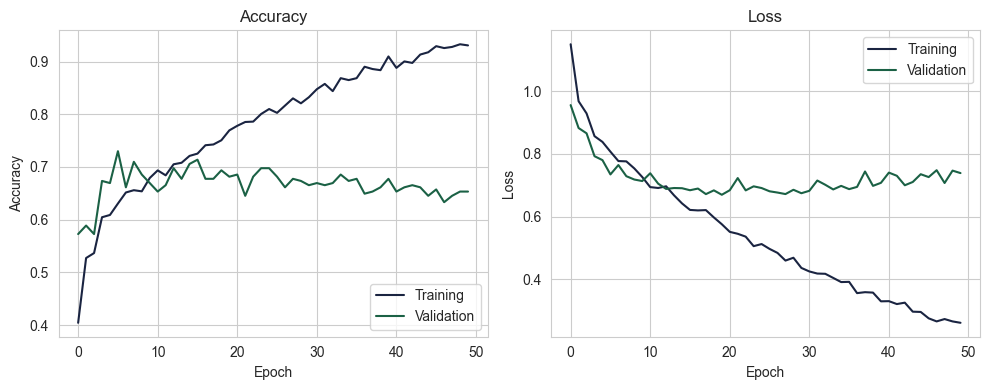

In [23]:
plot_metrics(d3_hist2)

In [24]:
def train_categorical_model3():
    train_data = np.load(location+'/bottleneck_features_train.npy')
    train_labels = np.array([0] * train_samples[0] + 
                            [1] * train_samples[1] + 
                            [2] * train_samples[2])
    train_labels = to_categorical(train_labels)

    validation_data = np.load(location+'/bottleneck_features_validation.npy')
    validation_labels = np.array([0] * (validation_samples[0]) + 
                                 [1] * (validation_samples[1]) +
                                 [2] * (validation_samples[2]))
    validation_labels = to_categorical(validation_labels)
    
    model = Sequential()
    model.add(Flatten(input_shape=train_data.shape[1:]))
    model.add(Dense(256, activation = 'relu',kernel_regularizer='l2'))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation = 'softmax'))

    model.compile(optimizer='rmsprop', 
                  loss='categorical_crossentropy', metrics=['accuracy']) 
    
    checkpoint = ModelCheckpoint(top_model_weights_path+"_3.hdf5", monitor='val_accuracy', 
                                 verbose=2, save_best_only=True, save_weights_only=True, mode='max')

    fit = model.fit(train_data, train_labels,
              epochs=nb_epoch, batch_size=16,
              validation_data=(validation_data, validation_labels),
              callbacks=[checkpoint])
    
    with open(location+'/top_history_3.txt', 'w') as f:
        json.dump(fit.history, f)
    
    return model, fit.history

In [25]:
d3_model3, d3_hist3 = train_categorical_model3() # l2 regularization and dropout

Epoch 1/50
87/87 [==============================] - ETA: 0s - loss: 4.1163 - accuracy: 0.4454
Epoch 1: val_accuracy improved from -inf to 0.54435, saving model to /Users/deepak/Music/dataset/data3a\top_model_weights_3.hdf5
87/87 [==============================] - 11s 127ms/step - loss: 4.1163 - accuracy: 0.4454 - val_loss: 1.1596 - val_accuracy: 0.5444
Epoch 2/50
87/87 [==============================] - ETA: 0s - loss: 1.2413 - accuracy: 0.4808
Epoch 2: val_accuracy improved from 0.54435 to 0.63306, saving model to /Users/deepak/Music/dataset/data3a\top_model_weights_3.hdf5
87/87 [==============================] - 11s 126ms/step - loss: 1.2413 - accuracy: 0.4808 - val_loss: 0.9349 - val_accuracy: 0.6331
Epoch 3/50
87/87 [==============================] - ETA: 0s - loss: 1.0608 - accuracy: 0.5495
Epoch 3: val_accuracy improved from 0.63306 to 0.64516, saving model to /Users/deepak/Music/dataset/data3a\top_model_weights_3.hdf5
87/87 [==============================] - 11s 121ms/step - los

Best Model:
epoch: 23 , val_accuracy: 0.7056451439857483 , val_loss: 0.8226583003997803


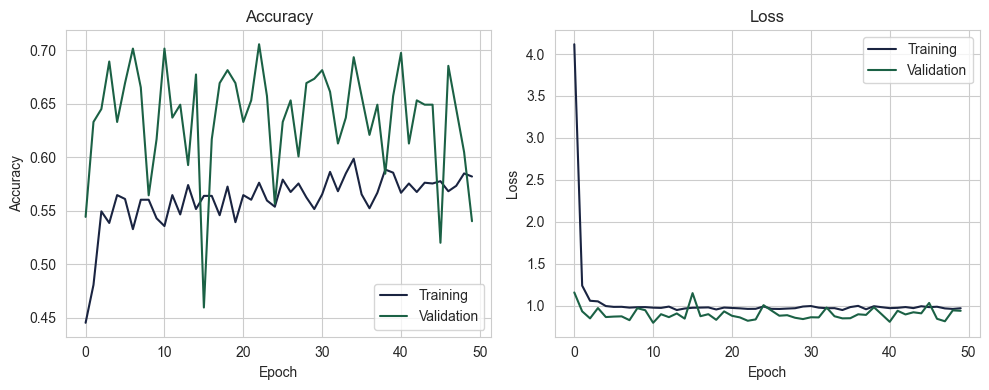

In [26]:
plot_metrics(d3_hist3)

## Finetuning Model

In [39]:
def finetune_categorical_model():
    model = load_vgg16()

    # build a classifier model to put on top of the convolutional model
    top_model = Sequential()
    top_model.add(Flatten(input_shape=model.output_shape[1:]))
    top_model.add(Dense(256, activation='relu'))
    top_model.add(Dropout(0.5))
    top_model.add(Dense(3, activation='softmax'))

    top_model.load_weights(top_model_weights_path) # load weights_path

    # add the model on top of the convolutional base
    model.add(top_model)
    
    # set the first 25 layers (up to the last conv block)
    # to non-trainable - weights will not be updated
    for layer in model.layers[:25]:
        layer.trainable=False

    model.compile(loss='categorical_crossentropy',
                 optimizer = optimizers.SGD(lr=0.000001, momentum=0.9), # reduced learning rate by 1/10
                  metrics=['accuracy'])
    
    # prepare data augmentation configuration
    train_datagen = ImageDataGenerator(rescale=1./255,
                                       rotation_range=40,
                                       width_shift_range=0.2,
                                       height_shift_range=0.2,
                                       shear_range=0.2,
                                       zoom_range=0.2,
                                       horizontal_flip=True,
                                       fill_mode='nearest')

    test_datagen = ImageDataGenerator(rescale=1./255)

    train_generator= train_datagen.flow_from_directory(train_data_dir,
                                                     target_size=(img_height, img_width),
                                                     batch_size=8,
                                                     class_mode='categorical')

    validation_generator = test_datagen.flow_from_directory(validation_data_dir,
                                                           target_size=(img_height, img_width),
                                                           batch_size=8,
                                                           class_mode='categorical')
    
    
    checkpoint = ModelCheckpoint(fine_tuned_model_path, monitor='val_acc', 
                                 verbose=1, save_best_only=True, 
                                 save_weights_only=False, mode='auto')
        
    # fine-tune the model
    fit = model.fit_generator(train_generator,
                              samples_per_epoch=nb_train_samples,
                              nb_epoch=nb_epoch,
                              validation_data=validation_generator,
                              nb_val_samples=nb_validation_samples,
                              verbose=1,
                              callbacks=[checkpoint])
    
    with open(location+'/ft_history.txt', 'wb') as f:
        json.dump(fit.history, f)
    
    return model, fit.history

### Run 1 - With Regularization

In [42]:
ft_d3_model1, ft_d3_hist1 = finetune_categorical_model1()

NameError: name 'finetune_categorical_model1' is not defined

In [ ]:
plot_metrics(ft_d3_hist1)

### Run 2 - Without Regularization

In [44]:
def finetune_categorical_model2():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256,256,3))

    top_model = Sequential()
    top_model.add(Flatten(input_shape=base_model.output_shape[1:]))
    top_model.add(Dense(256, activation='relu'))
    top_model.add(Dropout(0.5))
    top_model.add(Dense(3, activation='softmax'))

    top_model.load_weights(top_model_weights_path+"_3.hdf5") 

    model = Model(inputs=base_model.input, outputs=top_model(base_model.output))
    
    for layer in model.layers[:25]:
        layer.trainable=False

    model.compile(optimizer='rmsprop', 
                  loss='categorical_crossentropy', metrics=['accuracy']) 
    
    # prepare data augmentation configuration
    train_datagen = ImageDataGenerator(rescale=1./255,
                                       rotation_range=40,
                                       width_shift_range=0.2,
                                       height_shift_range=0.2,
                                       shear_range=0.2,
                                       zoom_range=0.2,
                                       horizontal_flip=True,
                                       fill_mode='nearest')

    test_datagen = ImageDataGenerator(rescale=1./255)

    train_generator= train_datagen.flow_from_directory(train_data_dir,
                                                     target_size=(img_height, img_width),
                                                     batch_size=8,
                                                     class_mode='categorical')

    validation_generator = test_datagen.flow_from_directory(validation_data_dir,
                                                           target_size=(img_height, img_width),
                                                           batch_size=8,
                                                           class_mode='categorical')
    
    
    checkpoint = ModelCheckpoint(fine_tuned_model_path+"_2.hdf5", monitor='val_accuracy', 
                                 verbose=2, save_best_only=True, 
                                 save_weights_only=False, mode='max')
        
    # fine-tune the model
    fit = model.fit(train_generator,
                              steps_per_epoch=nb_train_samples//batch_size,
                              epochs=nb_epoch,
                              validation_data=validation_generator,
                              validation_steps = nb_validation_samples//batch_size,
                              verbose=1,
                              callbacks=[checkpoint])
    
    with open(location+'/ft_history_2.txt', 'w') as f:
        json.dump(fit.history, f)
    
    return model, fit.history

In [46]:
ft_d3_model2, ft_d3_hist2 = finetune_categorical_model2()

Found 1383 images belonging to 3 classes.
Found 248 images belonging to 3 classes.
Epoch 1/50
86/86 [==============================] - ETA: 0s - loss: 0.9859 - accuracy: 0.5298
Epoch 1: val_accuracy improved from -inf to 0.70000, saving model to /Users/deepak/Music/dataset/data3a\ft_model_2.hdf5


C:\Users\deepak\AppData\Local\Programs\Python\Python38\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


86/86 [==============================] - 121s 1s/step - loss: 0.9859 - accuracy: 0.5298 - val_loss: 0.7112 - val_accuracy: 0.7000
Epoch 2/50
86/86 [==============================] - ETA: 0s - loss: 0.9709 - accuracy: 0.5109
Epoch 2: val_accuracy did not improve from 0.70000
86/86 [==============================] - 156s 2s/step - loss: 0.9709 - accuracy: 0.5109 - val_loss: 0.7059 - val_accuracy: 0.6667
Epoch 3/50
86/86 [==============================] - ETA: 0s - loss: 0.9251 - accuracy: 0.5357
Epoch 3: val_accuracy improved from 0.70000 to 0.70833, saving model to /Users/deepak/Music/dataset/data3a\ft_model_2.hdf5
86/86 [==============================] - 143s 2s/step - loss: 0.9251 - accuracy: 0.5357 - val_loss: 0.6987 - val_accuracy: 0.7083
Epoch 4/50
86/86 [==============================] - ETA: 0s - loss: 0.9585 - accuracy: 0.5313
Epoch 4: val_accuracy did not improve from 0.70833
86/86 [==============================] - 140s 2s/step - loss: 0.9585 - accuracy: 0.5313 - val_loss: 0.7

Best Model:
epoch: 12 , val_accuracy: 0.7583333253860474 , val_loss: 0.6689350605010986


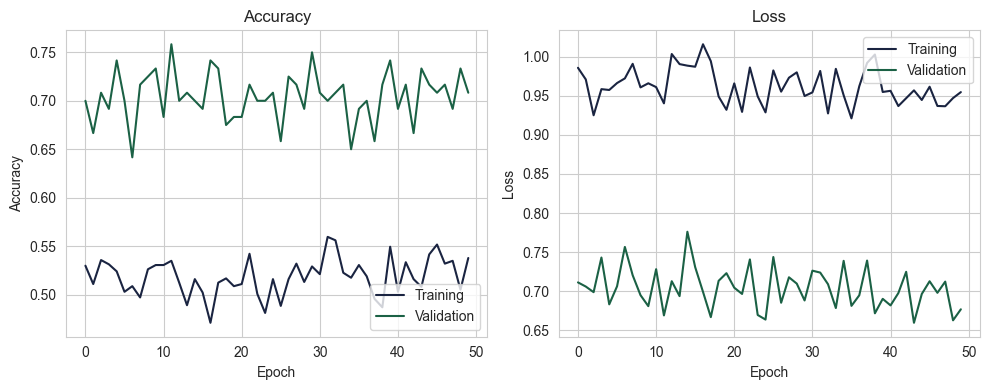

In [47]:
plot_metrics(ft_d3_hist2)

## Model Evaluation

In [101]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array


In [107]:
ft_d3_model1 = load_model(location+'/ft_model_2.hdf5') # with regularization, first run

In [ ]:
evaluate_categorical_model(ft_d3_model1, validation_data_dir, validation_labels) 

In [62]:
validation_labels = np.array([0] * validation_samples[0] + 
                             [1] * validation_samples[1] +
                             [2] * validation_samples[2])

In [58]:
ft_d3_model2 = load_model(location+'/ft_model_2.hdf5') # without regularization, first run

In [64]:
evaluate_categorical_model(ft_d3_model2, validation_data_dir, validation_labels)

Found 248 images belonging to 3 classes.


C:\Users\deepak\AppData\Local\Temp\ipykernel_16276\647296316.py:10: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions = model.predict_generator(generator, len(labels))



              precision    recall  f1-score   support

           0       0.82      0.80      0.81        82
           1       0.52      0.60      0.56        75
           2       0.79      0.70      0.74        91

    accuracy                           0.71       248
   macro avg       0.71      0.70      0.70       248
weighted avg       0.72      0.71      0.71       248




array([[66, 15,  1],
       [14, 45, 16],
       [ 0, 27, 64]], dtype=int64)

## Load Model Point

In [67]:
def plot_metrics(hist, stop=50):
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(4,6))
                            
    axes = axes.flatten()

    axes[0].plot(range(stop), hist['acc'], label='Training', color='#FF533D')
    axes[0].plot(range(stop), hist['val_acc'], label='Validation', color='#03507E')
    axes[0].set_title('Accuracy')
    axes[0].set_ylabel('Accuracy')
    
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='lower right')
                             
    axes[1].plot(range(stop), hist['loss'], label='Training', color='#FF533D')
    axes[1].plot(range(stop), hist['val_loss'], label='Validation', color='#03507E')
    axes[1].set_title('Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='upper right')
                             
    plt.tight_layout();
           
    print("Best Model:") 
    print_best_model_results(hist)

In [69]:
def evaluate_categorical_model(model, directory, labels):
    datagen = ImageDataGenerator(rescale=1./255)  

    generator = datagen.flow_from_directory(directory,
                                target_size=(img_height, img_width),
                                batch_size=8,
                                class_mode='categorical',
                                shuffle=False)
    
    predictions = model.predict_generator(generator, len(labels))
    pred_labels = np.argmax(predictions, axis=1)
    
    print('')
    print(classification_report(validation_labels, pred_labels))
    print('')
    cm = confusion_matrix(validation_labels, pred_labels)
    return cm

In [73]:
# WINNER
ft_model = load_model(location+'/ft_model_2.hdf5')  # without regularization, second run

In [75]:
with open(location+'/ft_history_2.txt') as f:    
    ft_history = json.load(f)

In [77]:
validation_labels = np.array([0] * validation_samples[0] + 
                             [1] * validation_samples[1] +
                             [2] * validation_samples[2])

In [79]:
cm = evaluate_categorical_model(ft_model, validation_data_dir, validation_labels)

Found 248 images belonging to 3 classes.


C:\Users\deepak\AppData\Local\Temp\ipykernel_16276\3770917814.py:10: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions = model.predict_generator(generator, len(labels))



              precision    recall  f1-score   support

           0       0.82      0.80      0.81        82
           1       0.52      0.60      0.56        75
           2       0.79      0.70      0.74        91

    accuracy                           0.71       248
   macro avg       0.71      0.70      0.70       248
weighted avg       0.72      0.71      0.71       248




In [80]:
with open(location+'/top_history_3.txt') as f:    
    top_history = json.load(f)

def plot_acc_metrics(hist1, hist2, stop=50):
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(4.25,7))
                            
    axes = axes.flatten()

    axes[0].plot(range(stop), hist1['accuracy'], label='Training', color='#FF533D')
    axes[0].plot(range(stop), hist1['val_accuracy'], label='Validation', color='#03507E')
    axes[0].set_title('Training')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='lower right')
                             
    axes[1].plot(range(stop), hist2['accuracy'], label='Training', color='#FF533D')
    axes[1].plot(range(stop), hist2['val_accuracy'], label='Validation', color='#03507E')
    axes[1].set_title('Fine-tuning')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='lower right')
                             
    plt.tight_layout();

In [82]:
heatmap_labels = ['Minor', 'Moderate', 'Severe']

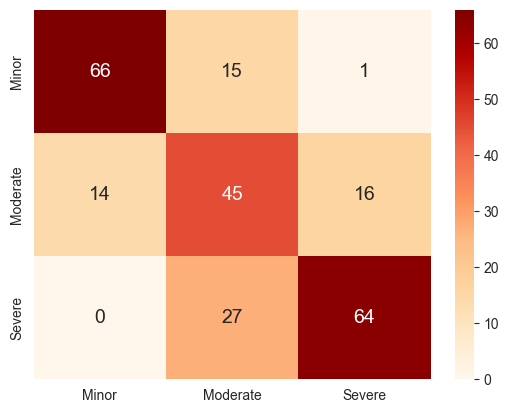

In [83]:
sns.heatmap(cm, annot=True, annot_kws={"size": 14}, 
            fmt='g', cmap='OrRd', xticklabels=heatmap_labels, yticklabels=heatmap_labels);

## Making Live Predictions

In [85]:
from urllib.request import urlretrieve
def severity_estimator(image_path, model,option=1):
    print("Determining severity of damage...")
    if(option==1):
      urlretrieve(image_path, 'save.jpg') # or other way to upload image
      img = load_img('save.jpg', target_size=(256, 256)) # this is a PIL image
    else:
      img = load_img(image_path,target_size=(256, 256)) 
    x = img_to_array(img) # this is a Numpy array with shape (3, 256, 256)
    x = x.reshape((1,) + x.shape)/255 # this is a Numpy array with shape (1, 3, 256, 256)
    pred = model.predict(x)
    print(pred)
    pred_label = np.argmax(pred, axis=1)
    d = {0: 'Minor', 1: 'Moderate', 2: 'Severe'}
    for key in d.keys():
        if pred_label[0] == key:
            print("Assessment: {} damage to vehicle".format(d[key]))
    print("Severity assessment complete.")

In [86]:
from urllib.request import urlretrieve
def severity_estimator(image_path, model,option=1):
    print("Determining severity of damage...")
    if(option==1):
      urlretrieve(image_path, 'save.jpg') # or other way to upload image
      img = load_img('save.jpg', target_size=(256, 256)) # this is a PIL image
    else:
      img = load_img(image_path,target_size=(256, 256)) 
    x = img_to_array(img) # this is a Numpy array with shape (3, 256, 256)
    x = x.reshape((1,) + x.shape)/255 # this is a Numpy array with shape (1, 3, 256, 256)
    pred = model.predict(x)
    print(pred)
    pred_label = np.argmax(pred, axis=1)
    d = {0: 'Minor', 1: 'Moderate', 2: 'Severe'}
    for key in d.keys():
        if pred_label[0] == key:
            print("Assessment: {} damage to vehicle".format(d[key]))
    print("Severity assessment complete.")

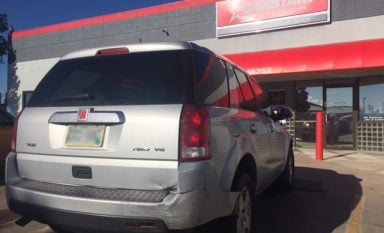

In [87]:
Image('https://www.nerdwallet.com/blog/wp-content/uploads/2015/12/exterior-car-damage-384x233.jpg')

In [109]:
severity_estimator('https://www.nerdwallet.com/blog/wp-content/uploads/2015/12/exterior-car-damage-384x233.jpg', ft_model)

Determining severity of damage...
1/1 [==============================] - 2s 2s/step
[[0.5329455 0.3896537 0.0774008]]
Assessment: Minor damage to vehicle
Severity assessment complete.


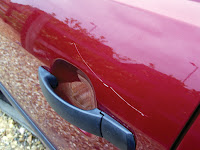

In [111]:
Image('http://1.bp.blogspot.com/-ToQS-qIxYbo/UDNuV5OcVQI/AAAAAAAABdo/tjeQywWiOo0/s200/Key+scratch.jpg')

In [112]:
severity_estimator('http://1.bp.blogspot.com/-ToQS-qIxYbo/UDNuV5OcVQI/AAAAAAAABdo/tjeQywWiOo0/s200/Key+scratch.jpg', ft_model)

Determining severity of damage...
1/1 [==============================] - 0s 196ms/step
[[0.6341306  0.32279292 0.04307652]]
Assessment: Minor damage to vehicle
Severity assessment complete.


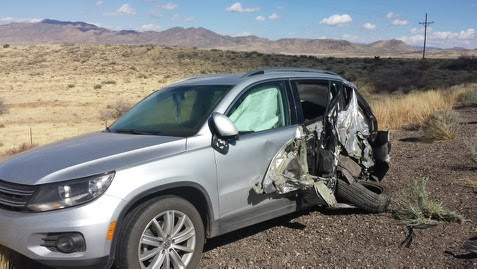

In [115]:
Image('http://1.bp.blogspot.com/-hzoFer11Gcw/Uw_b0Z8HGAI/AAAAAAAAA4M/XjV-NrRl0iM/s1600/20140227_140935.jpg')

In [116]:
severity_estimator('http://1.bp.blogspot.com/-hzoFer11Gcw/Uw_b0Z8HGAI/AAAAAAAAA4M/XjV-NrRl0iM/s1600/20140227_140935.jpg', ft_model)

Determining severity of damage...
1/1 [==============================] - 0s 241ms/step
[[0.07824841 0.48139718 0.44035444]]
Assessment: Moderate damage to vehicle
Severity assessment complete.


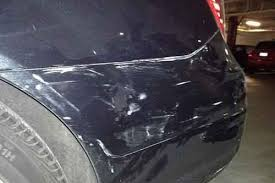

In [123]:
Image(location+'/validation/01-minor/0001.JPEG')

In [125]:
severity_estimator(location+'/validation/01-minor/0001.JPEG', ft_model,option=0)

Determining severity of damage...
1/1 [==============================] - 0s 236ms/step
[[0.68927693 0.2883291  0.02239392]]
Assessment: Minor damage to vehicle
Severity assessment complete.


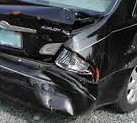

In [126]:
Image(location+'/validation/02-moderate/0002.JPEG')

In [127]:
severity_estimator(location+'/validation/02-moderate/0003.JPEG', ft_model,option=0)

Determining severity of damage...
1/1 [==============================] - 0s 194ms/step
[[0.3032187  0.49754992 0.19923146]]
Assessment: Moderate damage to vehicle
Severity assessment complete.


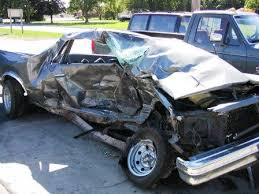

In [130]:
Image(location+'/validation/03-severe/0002.JPEG')

In [136]:
severity_estimator(location+'/validation/03-severe/0002.JPEG', ft_model,option=0)

Determining severity of damage...
1/1 [==============================] - 0s 175ms/step
[[0.00450718 0.24182977 0.75366306]]
Assessment: Severe damage to vehicle
Severity assessment complete.
